# Behavior Analysis Workbench: End-to-End Overview

Objective: run a complete pose-keypoint behavior-analysis smoke test from a local dataset through feature extraction, unsupervised discovery, motif labels, bout statistics, transition matrix, and visualizations.

Success criteria: this notebook runs with core dependencies only; heavier methods are listed but not required for the smoke path.

## Theoretical Basis

The pipeline is organized around three separable questions:

1. What pose geometry do we trust? (`DLC`, `SLEAP`, triangulation, or canonical local datasets)
2. What information do we preserve? (`raw_keypoints`, kinematics, spectral features, or learned embeddings)
3. How do we convert motion into behavior units? (clusters, HMM states, syllables, or hierarchical motifs)

This separation matters because a good cluster score can still come from a poor pose source, and a clean pose source can still be segmented badly if the feature block is mismatched to the behavior pattern.

## CEBRA In This Workbench

CEBRA is a **representation layer**, not the final discovery method. The key design choice is how we define anchor, positive, and negative relations.

- Anchor: one pose window or frame-level feature vector derived from `(T, K, D)`
- Positive pairs: nearby windows, same behavioral context, same weak label, or two augmentations of the same window
- Negative pairs: temporally distant windows or windows from different behaviors / conditions

Behavior-only use is valid because the pairing rule can come from temporal continuity instead of neural recordings. The method is learning behavioral geometry, not spike decoding.

Interpretation rule: a clean CEBRA embedding means the pairing rule preserved structure in pose space. It does **not** by itself prove biological correctness of the discovered clusters.


In [1]:
from pathlib import Path
import sys

ROOT = Path.cwd()
if ROOT.name != "behavior-lab":
    ROOT = Path("/Users/joon/dev/behavior-lab")
sys.path.insert(0, str(ROOT / "src"))

import numpy as np
try:
    import pandas as pd
except ImportError:
    pd = None
try:
    import matplotlib.pyplot as plt
except ImportError:
    plt = None

from behavior_lab.data.loaders import get_loader
from behavior_lab.data.features import (
    list_pose_sources, list_feature_blocks, list_discovery_methods,
)
from behavior_lab.experiments import compare_discovery_methods, extract_feature_matrix
from behavior_lab.evaluation import compute_behavior_metrics
if plt is not None:
    from behavior_lab.visualization.analysis import (
        plot_transition_matrix, plot_bout_duration, plot_temporal_raster,
    )

RANDOM_STATE = 42
MAX_FRAMES = 900
DATA_ROOT = ROOT / "data"
OUTPUT_DIR = ROOT / "outputs" / "behavior_analysis_workbench"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
np.random.seed(RANDOM_STATE)

def show_table(rows):
    if pd is not None:
        display(pd.DataFrame(rows))
    else:
        for row in rows:
            print(row)

## Module Catalog

These tables are generated from the reusable catalog module, so docs and notebooks share the same list of pose sources, feature blocks, and discovery methods.

In [2]:
def specs_to_rows(specs):
    return [
        {
            "name": s.name,
            "category": s.category,
            "input": s.input_format,
            "output": s.output_format,
            "module": s.module_path,
            "dependencies": ", ".join(s.dependencies),
        }
        for s in specs
    ]

show_table(specs_to_rows(list_pose_sources()))
show_table(specs_to_rows(list_feature_blocks()))
show_table(specs_to_rows(list_discovery_methods()))

,name,category,input,output,module,dependencies
0,DeepLabCut,pose_source,video or DLC h5/csv,"(T,K,2/3) keypoints + likelihood",scripts/*dlc*.sh; outputs/kp_benchmark/*.npz,deeplabcut
1,SLEAP,pose_source,.slp or SLEAP analysis .h5,"BehaviorSequence (T,K,D), flattened or per-track",behavior_lab.pose.sleap; behavior_lab.data.loa...,"sleap-io, h5py"
2,Anipose/Triangulation,pose_source,multi-view 2D keypoints + camera calibration,"(T,K,3) triangulated sparse keypoints",scripts/anipose_triangulate.py,opencv-python
3,Canonical NPZ loaders,pose_source,"CalMS21, MABe22, Rat7M, NTU, NW-UCLA, SUBTLE, ...","BehaviorSequence list with (T,K,D)",behavior_lab.data.loaders,"numpy, scipy, h5py"


,name,category,input,output,module,dependencies
0,raw_keypoints,feature,"(T,K,D)","(T,K*D)",numpy reshape,numpy
1,skeleton_kinematic,feature,"(T,K,D)","(T,4): speed, acceleration, spread, spatial va...",behavior_lab.data.features.SkeletonBackend,scipy
2,dyadic_egocentric,feature,"CalMS21 raw (T,2,2,7)","(T,24)",behavior_lab.data.features.dyadic.ego_centric_...,numpy
3,bsoid_spatiotemporal,feature,"(T,K,2/3)",10 fps displacement + pairwise distance + angu...,behavior_lab.models.discovery.bsoid._compute_b...,numpy
4,morlet_cwt,feature,"(T,K,D)",time-frequency spectral features,behavior_lab.data.features.morlet_backend.Morl...,scipy
5,self_supervised_embedding,feature,"windows of (T,K,D)",latent vectors,behavior_lab.models.ssl; behavior_lab.models.d...,torch


,name,category,input,output,module,dependencies
0,kmeans_pca_umap,discovery,"feature matrix (N,F)",labels + 2D embedding,behavior_lab.models.discovery.clustering.clust...,"scikit-learn, umap-learn"
1,B-SOiD,discovery,"(T,K,2/3)","10 fps labels, embedding, RF classifier",behavior_lab.models.discovery.bsoid.BSOiD,"umap-learn, hdbscan, scikit-learn"
2,keypoint-moseq,discovery,"(T,K,D)",syllable sequence + latent state,behavior_lab.models.discovery.moseq.KeypointMoSeq,keypoint-moseq
3,pca_hmm_fallback,discovery,"(T,K,D)",HMM state labels,behavior_lab.models.discovery.moseq._PCAHMMFal...,hmmlearn
4,SUBTLE,discovery,"(T,K,D)",hierarchical motif labels,behavior_lab.models.discovery.subtle_wrapper.S...,subtle
5,hBehaveMAE,discovery,windowed keypoints,hierarchical action/movement/activity clusters,behavior_lab.models.discovery.behavemae.BehaveMAE,torch


## Load A Local Test Dataset

Preference order: CalMS21, MABe22, NTU demo, then a deterministic synthetic fallback. The fallback keeps the notebook runnable even when raw datasets are absent.

In [3]:
def load_first_available_sequence():
    candidates = [
        ("calms21", DATA_ROOT / "calms21", "train"),
        ("mabe22", DATA_ROOT / "mabe22", "train"),
        ("ntu", DATA_ROOT / "ntu", "train"),
    ]
    for name, data_dir, split in candidates:
        if not data_dir.exists():
            continue
        try:
            loader = get_loader(name, data_dir=data_dir)
            if hasattr(loader, "load_split"):
                seqs = loader.load_split(split)
            else:
                seqs = loader.load_all()
            if seqs:
                return seqs[0], f"{name}:{split}"
        except Exception as exc:
            print(f"skip {name}: {exc}")

    t = np.linspace(0, 8 * np.pi, 1200)
    base = np.stack([np.sin(t), np.cos(t)], axis=1)
    offsets = np.array([[0, 0], [0.2, 0.1], [-0.2, 0.1], [0, -0.25], [0.15, -0.4]])
    keypoints = base[:, None, :] + offsets[None, :, :]
    keypoints += 0.03 * np.random.default_rng(RANDOM_STATE).normal(size=keypoints.shape)
    from behavior_lab.core.types import BehaviorSequence
    return BehaviorSequence(keypoints=keypoints.astype("float32"), fps=30, sample_id="synthetic"), "synthetic"

seq, dataset_name = load_first_available_sequence()
keypoints = np.nan_to_num(seq.keypoints[:MAX_FRAMES].astype("float32"))
print(dataset_name, seq.sample_id, keypoints.shape, "fps=", seq.fps)

calms21:train train_00000 (64, 14, 2) fps= 30.0


## Feature Baselines

## Interpretation Guide

- `raw_keypoints` is the least processed baseline and is useful for checking whether the geometry itself already separates states.
- `skeleton_kinematic` removes most coordinate-frame burden and emphasizes motion magnitude and body spread.
- Any unsupervised result here is descriptive, not a biological ground truth label.
- Transition matrices and bout durations are the first place to inspect whether a discovered state sequence behaves like a motif system rather than just a scattered partition of feature space.

In [4]:
raw_features = extract_feature_matrix(keypoints, feature="raw_keypoints", fps=seq.fps)
kin_features = extract_feature_matrix(keypoints, feature="skeleton_kinematic", fps=seq.fps)

feature_summary = [
    {"feature": "raw_keypoints", "shape": raw_features.shape, "mean": float(raw_features.mean()), "std": float(raw_features.std())},
    {"feature": "skeleton_kinematic", "shape": kin_features.shape, "mean": float(kin_features.mean()), "std": float(kin_features.std())},
]
show_table(feature_summary)

,feature,shape,mean,std
0,raw_keypoints,"(64, 28)",431.655090,200.322678
1,skeleton_kinematic,"(64, 4)",10065.452148,17414.789062


## Comparable Discovery Smoke Run

The core route uses PCA/UMAP/KMeans because it is deterministic enough for quick checks and avoids heavy optional installs. Add `bsoid`, `pca_hmm_fallback`, `subtle`, `moseq`, or `behavemae` when those extras are installed.

In [5]:
runs = compare_discovery_methods(
    keypoints,
    methods=("kmeans_pca_umap",),
    feature="skeleton_kinematic",
    fps=seq.fps,
    n_clusters=6,
    random_state=RANDOM_STATE,
)

rows = []
for run in runs:
    bm = run.behavior_metrics
    rows.append({
        "method": run.name,
        "feature": run.feature_name,
        "frames": run.result.num_frames,
        "clusters": run.result.n_clusters,
        "num_bouts": bm.num_bouts if bm else None,
        "mean_bout_s": np.mean(list(bm.bout_durations.values())) if bm and bm.bout_durations else None,
        "silhouette": (run.cluster_metrics or {}).get("silhouette"),
    })
results_rows = rows
show_table(results_rows)

/opt/anaconda3/envs/animal_behavior/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


,method,feature,frames,clusters,num_bouts,mean_bout_s,silhouette
0,kmeans_pca_umap,skeleton_kinematic,64,6,23,0.10873,0.0471


## Motif/Syllable Dynamics

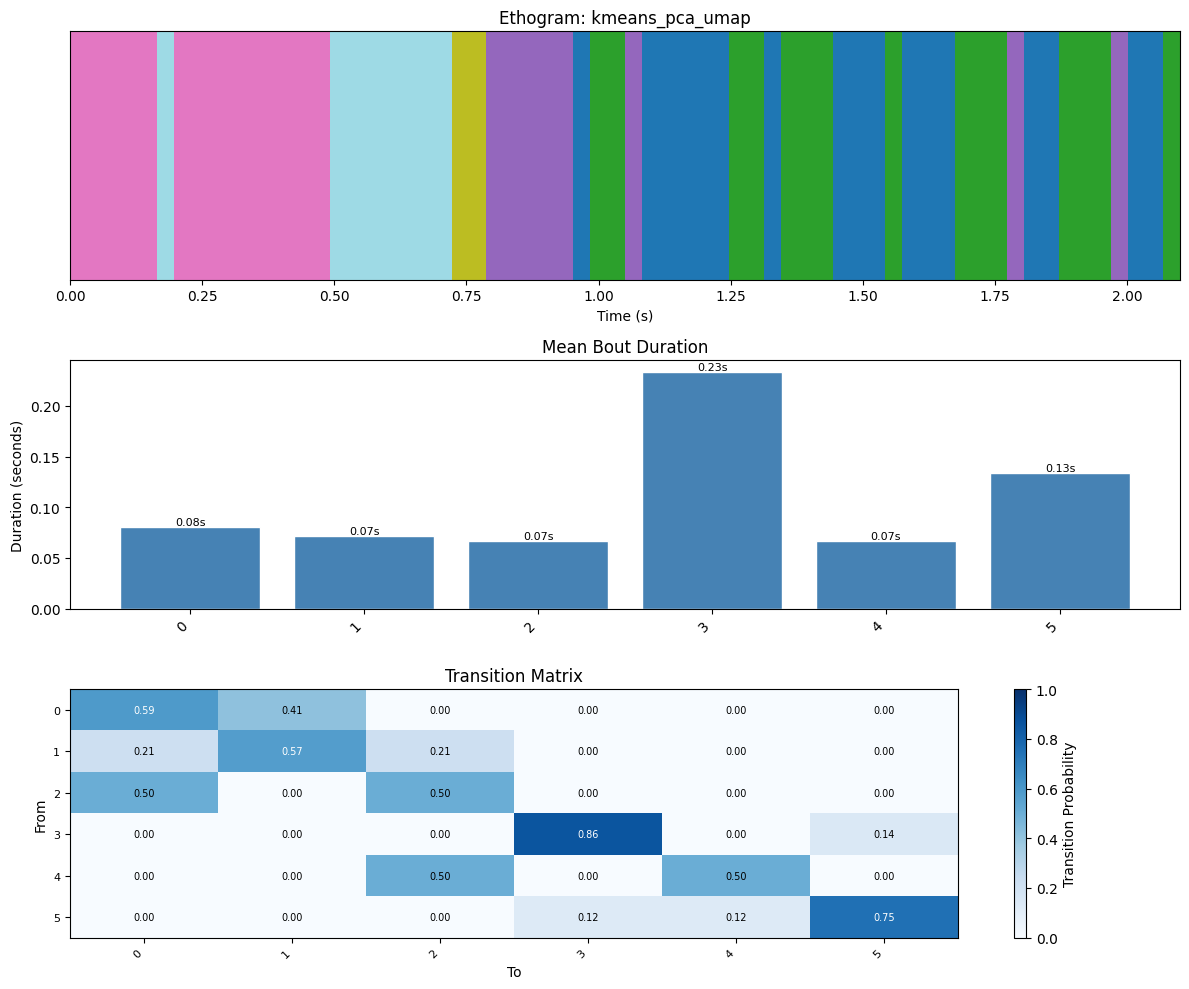

In [6]:
run = runs[0]
labels = run.result.labels
metrics = compute_behavior_metrics(labels, fps=seq.fps)

if plt is None:
    print("matplotlib is not installed; numeric behavior metrics are available below.")
    print("bout_durations", metrics.bout_durations)
    print("transition_matrix_shape", metrics.transition_matrix.shape)
else:
    fig, axes = plt.subplots(3, 1, figsize=(12, 10))
    plot_temporal_raster(labels, fps=seq.fps, title=f"Ethogram: {run.name}", ax=axes[0])
    plot_bout_duration(metrics.bout_durations, title="Mean Bout Duration", ax=axes[1])
    plot_transition_matrix(metrics.transition_matrix, title="Transition Matrix", ax=axes[2])
    fig.tight_layout()
    fig.savefig(OUTPUT_DIR / "00_overview_dynamics.png", dpi=150, bbox_inches="tight")
    plt.show()

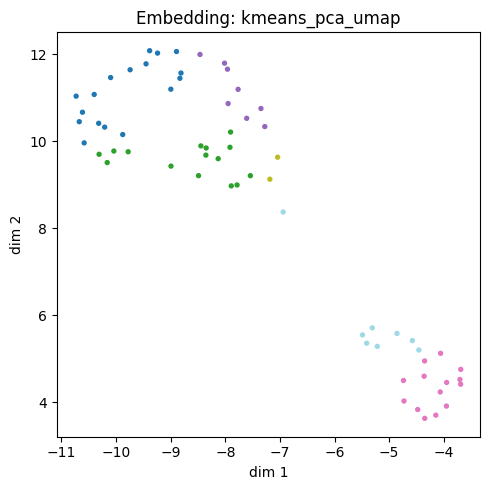

In [7]:
if run.result.embeddings is not None and plt is not None:
    emb = run.result.embeddings
    plt.figure(figsize=(5, 5))
    plt.scatter(emb[:, 0], emb[:, 1], c=labels, s=8, cmap="tab20")
    plt.title(f"Embedding: {run.name}")
    plt.xlabel("dim 1")
    plt.ylabel("dim 2")
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / "00_overview_embedding.png", dpi=150, bbox_inches="tight")
    plt.show()
elif run.result.embeddings is not None:
    print("embedding_shape", run.result.embeddings.shape)

## Notes

Use this notebook as the first-pass sanity check. For serious comparison, freeze dataset slice, preprocessing, feature block, method parameters, random seed, and label-alignment rules before interpreting metrics.